# EE 446 TinyML — Lab 3  
## Quantization of a DNN Using the UCI Human Activity Recognition Dataset

This is the **student version** of the lab notebook.

Complete all code cells marked with **TODO**.  
Use clear variable names and keep the overall notebook structure unchanged.


## 1. Environment Setup

Use the `Python (tinyml-arduino)` Jupyter kernel for this notebook.
All required packages are expected to be preinstalled in the course environment.


In [1]:
import sys
#!{sys.executable} -m pip install -q "tensorflow==2.15.1" "tensorflow-model-optimization==0.8.0" "scikit-learn==1.4.2" "pandas==2.2.2" "matplotlib==3.8.4"


## 2. Imports and Reproducibility


In [2]:
import os
import zipfile
import pathlib
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_model_optimization as tfmot

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("TF-MOT version:", tfmot.__version__)


TensorFlow version: 2.14.1
TF-MOT version: 0.8.0


## 3. Download and Extract the UCI HAR Dataset

The original dataset contains:
- **561 numerical features** extracted from smartphone sensor signals
- **6 activity classes**
- predefined **training** and **test** splits

The code below downloads and extracts the dataset if it is not already present.


In [3]:
dataset_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip"
zip_path = "uci_har_dataset.zip"
extract_dir = "."

if not os.path.exists("UCI HAR Dataset"):
    !wget -q "{dataset_url}" -O "{zip_path}"
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(extract_dir)
    print("Dataset downloaded and extracted.")
else:
    print("Dataset directory already exists.")


Dataset directory already exists.


## 4. Load the Data


In [4]:
def load_har_data(root_dir="UCI HAR Dataset"):
    # TODO:
    # 1. Load X_train from train/X_train.txt
    # 2. Load y_train from train/y_train.txt
    # 3. Load X_test from test/X_test.txt
    # 4. Load y_test from test/y_test.txt
    # 5. Convert the labels to zero-based class indices by subtracting 1
    # <-- Enter your code here <--#
    X_train = np.loadtxt(os.path.join(root_dir, "train", "X_train.txt"))
    y_train = np.loadtxt(os.path.join(root_dir, "train", "y_train.txt")).astype(int) - 1
    X_test = np.loadtxt(os.path.join(root_dir, "test", "X_test.txt"))
    y_test = np.loadtxt(os.path.join(root_dir, "test", "y_test.txt")).astype(int) - 1
    return X_train, y_train, X_test, y_test

X_train, y_train, X_test, y_test = load_har_data()

class_names = [
    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING"
]

# TODO: define num_features and num_classes
# <-- Enter your code here <--#
num_features = X_train.shape[1]
num_classes = len(np.unique(y_train))

## 5. Quick Inspection


In [5]:
# TODO:
# Create a small summary table showing the class index, class name, and number of training samples.

# <-- Enter your code here <--#
counts = np.bincount(y_train)
df_inspect = pd.DataFrame({
    "Class Index": range(num_classes),
    "Class Name": class_names,
    "Training Samples": counts
})
print(df_inspect.to_string(index=False))

 Class Index         Class Name  Training Samples
           0            WALKING              1226
           1   WALKING_UPSTAIRS              1073
           2 WALKING_DOWNSTAIRS               986
           3            SITTING              1286
           4           STANDING              1374
           5             LAYING              1407


## 6. Train a Baseline DNN

We will use a compact dense neural network that is appropriate for a numerical-feature TinyML-style workflow.

### Architecture
- Input: 561 features
- Dense(256, ReLU)
- Dense(128, ReLU)
- Dense(64, ReLU)
- Dense(6, Softmax)


In [6]:
def build_baseline_model(input_dim, num_classes):
    # TODO:
    # Build and compile a DNN with the following architecture:
    # Input -> Dense(256, relu) -> Dense(128, relu) -> Dense(64, relu) -> Dense(num_classes, softmax)
    # Use Adam with learning rate 1e-3.
    # Use sparse_categorical_crossentropy as the loss.
    # Track accuracy as a metric.

    # <-- Enter your code here <--#
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(256, activation='relu'),
        layers.Dense(128, activation='relu'),
        layers.Dense(64, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer=keras.optimizers.Adam(1e-3),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model
    #raise NotImplementedError("Complete the baseline DNN.")

baseline_model = build_baseline_model(num_features, num_classes)
baseline_model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 256)               143872    
                                                                 
 dense_1 (Dense)             (None, 128)               32896     
                                                                 
 dense_2 (Dense)             (None, 64)                8256      
                                                                 
 dense_3 (Dense)             (None, 6)                 390       
                                                                 
Total params: 185414 (724.27 KB)
Trainable params: 185414 (724.27 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


### Train the Baseline Model


In [7]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        restore_best_weights=True
    )
]

# TODO:
# Train the baseline model using:
# - validation_split=0.2
# - epochs=40
# - batch_size=64
# - callbacks=callbacks

# <-- Enter your code here <--#
history = baseline_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=40,
    batch_size=64,
    callbacks=callbacks
)

Epoch 1/40
92/92 [==============================] - 0s 2ms/step - loss: 0.4880 - accuracy: 0.8075 - val_loss: 0.2016 - val_accuracy: 0.9245
Epoch 2/40
92/92 [==============================] - 0s 2ms/step - loss: 0.1638 - accuracy: 0.9374 - val_loss: 0.1399 - val_accuracy: 0.9375
Epoch 3/40
92/92 [==============================] - 0s 2ms/step - loss: 0.1152 - accuracy: 0.9568 - val_loss: 0.2632 - val_accuracy: 0.9123
Epoch 4/40
92/92 [==============================] - 0s 2ms/step - loss: 0.0907 - accuracy: 0.9633 - val_loss: 0.1618 - val_accuracy: 0.9402
Epoch 5/40
92/92 [==============================] - 0s 2ms/step - loss: 0.0905 - accuracy: 0.9646 - val_loss: 0.2719 - val_accuracy: 0.9205
Epoch 6/40
92/92 [==============================] - 0s 2ms/step - loss: 0.0712 - accuracy: 0.9723 - val_loss: 0.2235 - val_accuracy: 0.9307
Epoch 7/40
92/92 [==============================] - 0s 2ms/step - loss: 0.0588 - accuracy: 0.9776 - val_loss: 0.1442 - val_accuracy: 0.9422
Epoch 8/40
92/92 [==

### Training Curves


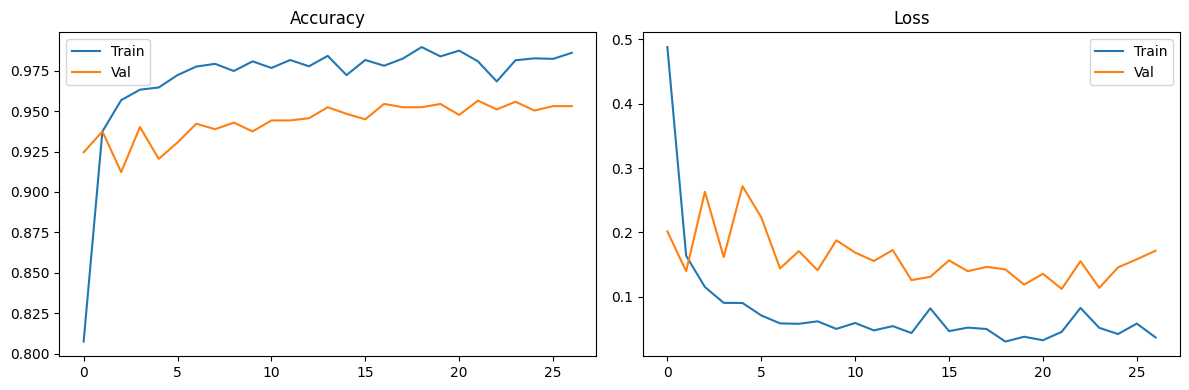

In [8]:
# TODO:
# Plot the training and validation accuracy.
# Plot the training and validation loss.

# <-- Enter your code here <--#
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['accuracy'], label='Train')
axes[0].plot(history.history['val_accuracy'], label='Val')
axes[0].set_title('Accuracy'); axes[0].legend()
axes[1].plot(history.history['loss'], label='Train')
axes[1].plot(history.history['val_loss'], label='Val')
axes[1].set_title('Loss'); axes[1].legend()
plt.tight_layout(); plt.show()

## 7. Evaluate the Baseline Keras Model


93/93 [==============================] - 0s 880us/step
Baseline Test Accuracy: 0.9264
                    precision    recall  f1-score   support

           WALKING       0.86      1.00      0.92       496
  WALKING_UPSTAIRS       0.95      0.85      0.90       471
WALKING_DOWNSTAIRS       0.97      0.91      0.94       420
           SITTING       0.93      0.89      0.91       491
          STANDING       0.87      0.94      0.90       532
            LAYING       1.00      0.96      0.98       537

          accuracy                           0.93      2947
         macro avg       0.93      0.92      0.93      2947
      weighted avg       0.93      0.93      0.93      2947



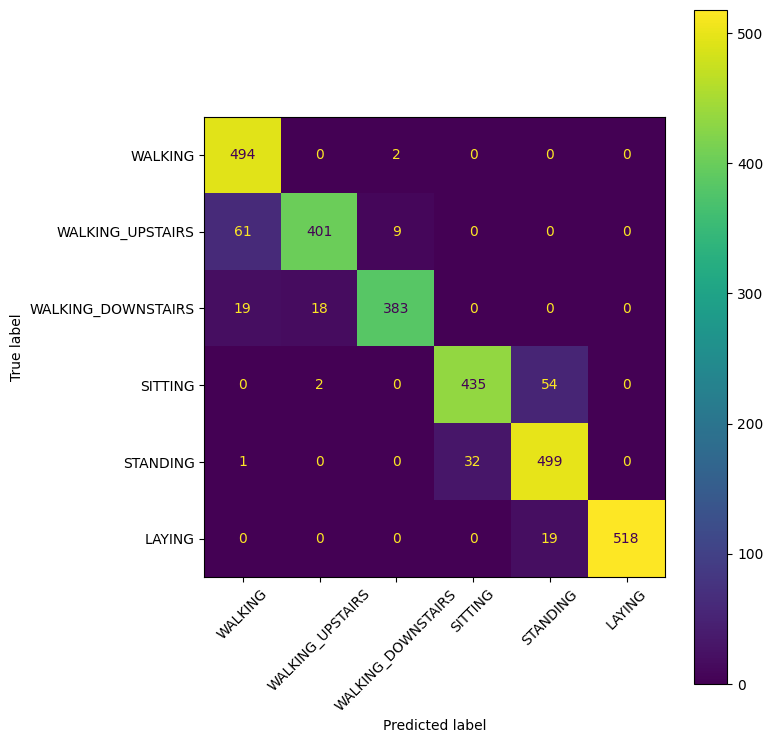

In [9]:
# TODO:
# 1. Obtain predicted probabilities on X_test
# 2. Convert them to class predictions using argmax
# 3. Compute test accuracy
# 4. Print the classification report
# 5. Plot the confusion matrix

# <-- Enter your code here <--#
y_prob = baseline_model.predict(X_test)
y_pred = np.argmax(y_prob, axis=1)
acc = accuracy_score(y_test, y_pred)
print(f"Baseline Test Accuracy: {acc:.4f}")
print(classification_report(y_test, y_pred, target_names=class_names))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(8,8))
disp.plot(ax=ax, xticks_rotation=45)
plt.tight_layout()
plt.show()

## 8. TensorFlow Lite Utilities

The following helper functions are used to:
- convert Keras models to TensorFlow Lite,
- evaluate TensorFlow Lite models on the test set, and
- measure model file size.


In [10]:
def save_binary_model(model_content, filename):
    with open(filename, "wb") as f:
        f.write(model_content)
    return os.path.getsize(filename) / 1024.0  # KB

def representative_dataset_gen():
    # TODO:
    # Yield 300 representative samples from X_train as float32 tensors.
    # Each yielded item should be in the form: [sample]
    
    # <-- Enter your code here <--#
    for i in range(300):
        yield [X_train[i:i+1].astype(np.float32)]
    #raise NotImplementedError("Complete the representative dataset generator.")

def evaluate_tflite_model(tflite_model, X, y_true):
    interpreter = tf.lite.Interpreter(model_content=tflite_model)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    input_scale, input_zero_point = input_details["quantization"]
    output_scale, output_zero_point = output_details["quantization"]

    y_pred = []

    for i in range(len(X)):
        x = X[i:i+1].astype(np.float32)

        # TODO:
        # Quantize the input only when the input dtype is int8 or uint8.
        # Otherwise keep the input in the required floating-point dtype.

        # <-- Enter your code here <--#
        if input_details["dtype"] in [np.int8, np.uint8]:
            x = (x / input_scale + input_zero_point).astype(input_details["dtype"])
        else:
            x = x.astype(input_details["dtype"])

        interpreter.set_tensor(input_details["index"], x)
        interpreter.invoke()

        output = interpreter.get_tensor(output_details["index"])

        # TODO:
        # If the output is quantized, dequantize it back to float32.

        # <-- Enter your code here <--#
        if output_details["dtype"] in [np.int8, np.uint8]:
            output = (output.astype(np.float32) - output_zero_point) * output_scale

        y_pred.append(np.argmax(output, axis=1)[0])

    y_pred = np.array(y_pred)
    acc = accuracy_score(y_true, y_pred)
    return acc, y_pred

def convert_to_tflite_fp32(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    # TODO: return the converted FP32 TensorFlow Lite model
    # <-- Enter your code here <--#
    return converter.convert()

def convert_to_tflite_dynamic_range(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    # TODO:
    # Apply default optimization and return the converted model.

    # <-- Enter your code here <--#
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    return converter.convert()

def convert_to_tflite_float16(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    # TODO:
    # Apply default optimization
    # Set supported_types to [tf.float16]
    # Return the converted model

    # <-- Enter your code here <--#
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.target_spec.supported_types = [tf.float16]
    return converter.convert()

def convert_to_tflite_int8(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    # TODO:
    # Apply default optimization
    # Attach representative_dataset_gen
    # Restrict to TFLITE_BUILTINS_INT8
    # Set inference_input_type and inference_output_type to tf.int8
    # Return the converted model

    # <-- Enter your code here <--#
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.representative_dataset = representative_dataset_gen
    converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
    converter.inference_input_type = tf.int8
    converter.inference_output_type = tf.int8
    return converter.convert()


## 9. Post-Training Quantization (PTQ)


In [11]:
# TODO:
# Convert the baseline model into:
# - FP32 TFLite
# - dynamic range TFLite
# - float16 TFLite
# - int8 TFLite

# Save each model to disk and record its size in KB.
# Evaluate each TFLite model on the test set.

# <-- Enter your code here <--#
tflite_fp32 = convert_to_tflite_fp32(baseline_model)
tflite_drq = convert_to_tflite_dynamic_range(baseline_model)
tflite_fp16 = convert_to_tflite_float16(baseline_model)
tflite_int8 = convert_to_tflite_int8(baseline_model)

size_fp32 = save_binary_model(tflite_fp32, "baseline_fp32.tflite")
size_drq = save_binary_model(tflite_drq, "baseline_drq.tflite")
size_fp16 = save_binary_model(tflite_fp16, "baseline_fp16.tflite")
size_int8 = save_binary_model(tflite_int8, "baseline_int8.tflite")

acc_fp32, _ = evaluate_tflite_model(tflite_fp32, X_test, y_test)
acc_drq, _ = evaluate_tflite_model(tflite_drq, X_test, y_test)
acc_fp16, _ = evaluate_tflite_model(tflite_fp16, X_test, y_test)
acc_int8, pred_int8 = evaluate_tflite_model(tflite_int8, X_test, y_test)

print(f"FP32:          acc={acc_fp32:.4f}, size={size_fp32:.1f} KB")
print(f"Dynamic Range: acc={acc_drq:.4f}, size={size_drq:.1f} KB")
print(f"Float16:       acc={acc_fp16:.4f}, size={size_fp16:.1f} KB")
print(f"INT8:          acc={acc_int8:.4f}, size={size_int8:.1f} KB")


INFO:tensorflow:Assets written to: /var/folders/_p/zqhpnqps1h95cxmcwntmhcnh0000gn/T/tmp2u5jxcv7/assets


INFO:tensorflow:Assets written to: /var/folders/_p/zqhpnqps1h95cxmcwntmhcnh0000gn/T/tmp2u5jxcv7/assets
2026-04-21 20:53:05.142415: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-21 20:53:05.142426: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-21 20:53:05.142757: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/_p/zqhpnqps1h95cxmcwntmhcnh0000gn/T/tmp2u5jxcv7
2026-04-21 20:53:05.143197: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-21 20:53:05.143201: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/_p/zqhpnqps1h95cxmcwntmhcnh0000gn/T/tmp2u5jxcv7
2026-04-21 20:53:05.144454: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:382] MLIR V1 optimization pass is not enabled
2026-04-21 20:53:05.145045: I tensorflow/cc/saved_model/load

INFO:tensorflow:Assets written to: /var/folders/_p/zqhpnqps1h95cxmcwntmhcnh0000gn/T/tmp4nacmbdt/assets


INFO:tensorflow:Assets written to: /var/folders/_p/zqhpnqps1h95cxmcwntmhcnh0000gn/T/tmp4nacmbdt/assets
2026-04-21 20:53:05.474807: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-21 20:53:05.474817: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-21 20:53:05.474918: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/_p/zqhpnqps1h95cxmcwntmhcnh0000gn/T/tmp4nacmbdt
2026-04-21 20:53:05.475410: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-21 20:53:05.475415: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/_p/zqhpnqps1h95cxmcwntmhcnh0000gn/T/tmp4nacmbdt
2026-04-21 20:53:05.476658: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-21 20:53:05.497878: I tensorflow/cc/saved_model/loader.cc:217] Running initialization

INFO:tensorflow:Assets written to: /var/folders/_p/zqhpnqps1h95cxmcwntmhcnh0000gn/T/tmpjl0nvnwa/assets


INFO:tensorflow:Assets written to: /var/folders/_p/zqhpnqps1h95cxmcwntmhcnh0000gn/T/tmpjl0nvnwa/assets
2026-04-21 20:53:05.803081: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-21 20:53:05.803096: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-21 20:53:05.803182: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/_p/zqhpnqps1h95cxmcwntmhcnh0000gn/T/tmpjl0nvnwa
2026-04-21 20:53:05.803656: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-21 20:53:05.803661: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/_p/zqhpnqps1h95cxmcwntmhcnh0000gn/T/tmpjl0nvnwa
2026-04-21 20:53:05.804903: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-21 20:53:05.824561: I tensorflow/cc/saved_model/loader.cc:217] Running initialization

INFO:tensorflow:Assets written to: /var/folders/_p/zqhpnqps1h95cxmcwntmhcnh0000gn/T/tmpxynxmqi_/assets


INFO:tensorflow:Assets written to: /var/folders/_p/zqhpnqps1h95cxmcwntmhcnh0000gn/T/tmpxynxmqi_/assets
/Users/mac/ai/projects/tinyml-arduino/lib/python3.11/site-packages/tensorflow/lite/python/convert.py:947: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
2026-04-21 20:53:06.174813: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-21 20:53:06.174822: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-21 20:53:06.174912: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/_p/zqhpnqps1h95cxmcwntmhcnh0000gn/T/tmpxynxmqi_
2026-04-21 20:53:06.175330: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-21 20:53:06.175335: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/_p/zqhpnqps1h95cxmcw

FP32:          acc=0.9264, size=726.7 KB
Dynamic Range: acc=0.9260, size=186.1 KB
Float16:       acc=0.9264, size=365.7 KB
INT8:          acc=0.9260, size=185.3 KB


## 10. PTQ Comparison: Accuracy and Model Size


In [12]:
# TODO:
# Create a comparison DataFrame containing:
# Model Family, Format, Test Accuracy, Model Size (KB)

# <-- Enter your code here <--#
df_ptq = pd.DataFrame({
    "Model Family": ["Baseline PTQ"] * 4,
    "Format": ["FP32", "Dynamic Range", "Float16", "INT8"],
    "Test Accuracy": [acc_fp32, acc_drq, acc_fp16, acc_int8],
    "Model Size (KB)": [size_fp32, size_drq, size_fp16, size_int8]
})
print(df_ptq.to_string(index=False))


Model Family        Format  Test Accuracy  Model Size (KB)
Baseline PTQ          FP32       0.926366       726.718750
Baseline PTQ Dynamic Range       0.926026       186.109375
Baseline PTQ       Float16       0.926366       365.710938
Baseline PTQ          INT8       0.926026       185.335938


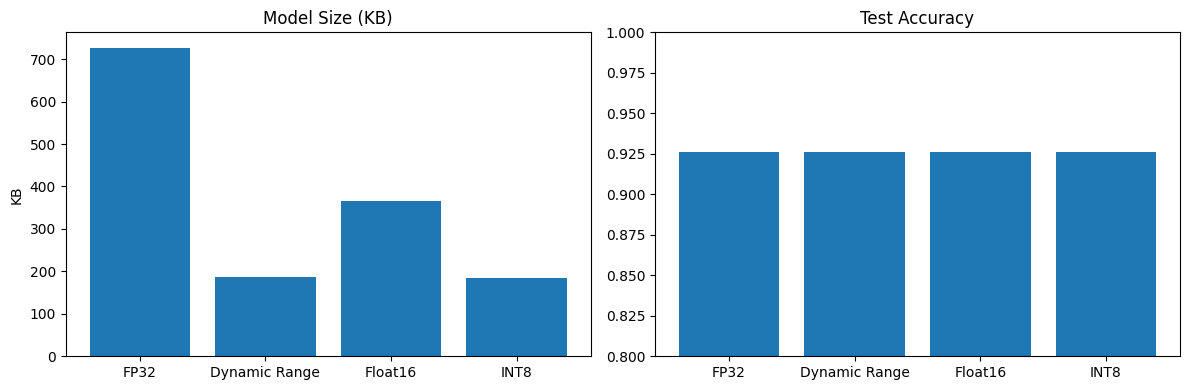

In [13]:
# TODO:
# Create one bar plot for model size and another for test accuracy.

# <-- Enter your code here <--#
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(df_ptq["Format"], df_ptq["Model Size (KB)"])
axes[0].set_title("Model Size (KB)")
axes[0].set_ylabel("KB")
axes[1].bar(df_ptq["Format"], df_ptq["Test Accuracy"])
axes[1].set_title("Test Accuracy")
axes[1].set_ylim(0.8, 1.0)
plt.tight_layout()
plt.show()

### Confusion Matrix for the PTQ Int8 Model


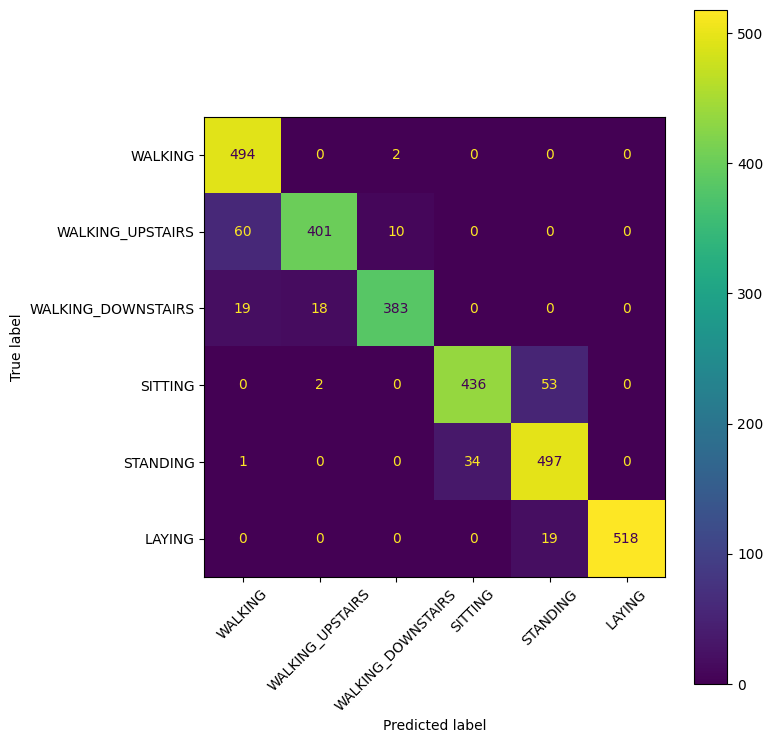

                    precision    recall  f1-score   support

           WALKING       0.86      1.00      0.92       496
  WALKING_UPSTAIRS       0.95      0.85      0.90       471
WALKING_DOWNSTAIRS       0.97      0.91      0.94       420
           SITTING       0.93      0.89      0.91       491
          STANDING       0.87      0.93      0.90       532
            LAYING       1.00      0.96      0.98       537

          accuracy                           0.93      2947
         macro avg       0.93      0.92      0.93      2947
      weighted avg       0.93      0.93      0.93      2947



In [14]:
# TODO:
# Plot the confusion matrix for the PTQ int8 model.
# Print the classification report for the PTQ int8 model.

# <-- Enter your code here <--#
cm_int8 = confusion_matrix(y_test, pred_int8)
disp = ConfusionMatrixDisplay(cm_int8, display_labels=class_names)
fig, ax = plt.subplots(figsize=(8,8))
disp.plot(ax=ax, xticks_rotation=45)
plt.tight_layout()
plt.show()
print(classification_report(y_test, pred_int8, target_names=class_names))

## 11. Quantization-Aware Training (QAT)

QAT simulates quantization effects during training so that the final model is usually more robust after conversion to int8.


In [15]:
# TODO:
# Create a QAT model from the trained baseline model using TF-MOT.
# Compile it with Adam(1e-4), sparse_categorical_crossentropy, and accuracy.

# <-- Enter your code here <--#
qat_model = tfmot.quantization.keras.quantize_model(baseline_model)
qat_model.compile(optimizer=keras.optimizers.Adam(1e-4),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

### Fine-Tune the QAT Model


In [16]:
# TODO:
# Fine-tune the QAT model for 8 epochs using validation_split=0.2 and batch_size=64.

# <-- Enter your code here <--#
qat_history = qat_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=8,
    batch_size=64
)

Epoch 1/8
92/92 [==============================] - 1s 3ms/step - loss: 0.0283 - accuracy: 0.9917 - val_loss: 0.1256 - val_accuracy: 0.9579
Epoch 2/8
92/92 [==============================] - 0s 2ms/step - loss: 0.0236 - accuracy: 0.9915 - val_loss: 0.1253 - val_accuracy: 0.9585
Epoch 3/8
92/92 [==============================] - 0s 2ms/step - loss: 0.0223 - accuracy: 0.9929 - val_loss: 0.1286 - val_accuracy: 0.9572
Epoch 4/8
92/92 [==============================] - 0s 2ms/step - loss: 0.0207 - accuracy: 0.9929 - val_loss: 0.1269 - val_accuracy: 0.9579
Epoch 5/8
92/92 [==============================] - 0s 2ms/step - loss: 0.0195 - accuracy: 0.9935 - val_loss: 0.1533 - val_accuracy: 0.9551
Epoch 6/8
92/92 [==============================] - 0s 2ms/step - loss: 0.0215 - accuracy: 0.9920 - val_loss: 0.1419 - val_accuracy: 0.9572
Epoch 7/8
92/92 [==============================] - 0s 2ms/step - loss: 0.0190 - accuracy: 0.9932 - val_loss: 0.1332 - val_accuracy: 0.9585
Epoch 8/8
92/92 [==========

### Evaluate the QAT Keras Model


In [17]:
# TODO:
# Evaluate the QAT Keras model on X_test.
# Print the test accuracy and classification report.

# <-- Enter your code here <--#
qat_loss, qat_acc = qat_model.evaluate(X_test, y_test, verbose=0)
print(f"QAT Keras Test Accuracy: {qat_acc:.4f}")
y_qat_pred = np.argmax(qat_model.predict(X_test), axis=1)
print(classification_report(y_test, y_qat_pred, target_names=class_names))

QAT Keras Test Accuracy: 0.9362
93/93 [==============================] - 0s 589us/step
                    precision    recall  f1-score   support

           WALKING       0.93      0.98      0.95       496
  WALKING_UPSTAIRS       0.92      0.93      0.92       471
WALKING_DOWNSTAIRS       0.97      0.92      0.94       420
           SITTING       0.96      0.87      0.91       491
          STANDING       0.86      0.97      0.91       532
            LAYING       1.00      0.95      0.98       537

          accuracy                           0.94      2947
         macro avg       0.94      0.93      0.94      2947
      weighted avg       0.94      0.94      0.94      2947



### Convert the QAT Model to Int8 TensorFlow Lite


In [18]:
# TODO:
# Convert the QAT model to int8 TensorFlow Lite.
# Save the model, compute its size, and evaluate it on the test set.

# <-- Enter your code here <--#
tflite_qat_int8 = convert_to_tflite_int8(qat_model)
size_qat_int8 = save_binary_model(tflite_qat_int8, "qat_int8.tflite")
acc_qat_int8, pred_qat_int8 = evaluate_tflite_model(tflite_qat_int8, X_test, y_test)
print(f"QAT INT8: acc={acc_qat_int8:.4f}, size={size_qat_int8:.1f} KB")

INFO:tensorflow:Assets written to: /var/folders/_p/zqhpnqps1h95cxmcwntmhcnh0000gn/T/tmpc10jacn1/assets


INFO:tensorflow:Assets written to: /var/folders/_p/zqhpnqps1h95cxmcwntmhcnh0000gn/T/tmpc10jacn1/assets
/Users/mac/ai/projects/tinyml-arduino/lib/python3.11/site-packages/tensorflow/lite/python/convert.py:947: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


QAT INT8: acc=0.9365, size=185.7 KB


2026-04-21 20:53:09.913410: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-21 20:53:09.913423: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-21 20:53:09.913511: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/_p/zqhpnqps1h95cxmcwntmhcnh0000gn/T/tmpc10jacn1
2026-04-21 20:53:09.914595: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-21 20:53:09.914599: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/_p/zqhpnqps1h95cxmcwntmhcnh0000gn/T/tmpc10jacn1
2026-04-21 20:53:09.917295: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-21 20:53:09.949025: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /var/folders/_p/zqhpnqps1h95cxmcwntmhcnh0000gn/T/tmpc10jacn1
2026-04-

## 12. PTQ Int8 vs QAT Int8


In [19]:
# TODO:
# Create a DataFrame comparing PTQ int8 and QAT int8:
# Model, Test Accuracy, Model Size (KB)

# <-- Enter your code here <--#
df_compare = pd.DataFrame({
    "Model": ["PTQ INT8", "QAT INT8"],
    "Test Accuracy": [acc_int8, acc_qat_int8],
    "Model Size (KB)": [size_int8, size_qat_int8]
})
print(df_compare.to_string(index=False))


   Model  Test Accuracy  Model Size (KB)
PTQ INT8       0.926026       185.335938
QAT INT8       0.936546       185.695312


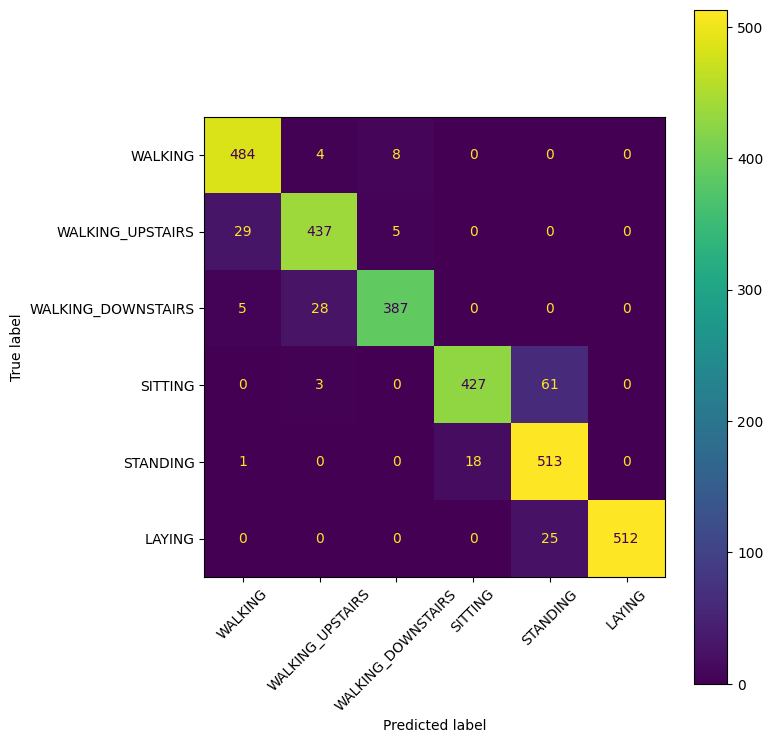

In [20]:
# TODO:
# Plot the confusion matrix for the QAT int8 model.

# <-- Enter your code here <--#
cm_qat = confusion_matrix(y_test, pred_qat_int8)
disp = ConfusionMatrixDisplay(cm_qat, display_labels=class_names)
fig, ax = plt.subplots(figsize=(8,8))
disp.plot(ax=ax, xticks_rotation=45)
plt.tight_layout()
plt.show()


## 13. Summary Questions

Write short answers to the following:
1. Which quantization method gave the smallest model size?
2. Which quantization method gave the best accuracy among the TensorFlow Lite models?
3. Did QAT improve the final int8 model compared with PTQ int8?
4. Why is this dataset a good fit for a DNN-based TinyML workflow?
5. If you were deploying this model on a resource-constrained device, which version would you choose and why?


1.INT8 quantization gave the smallest model size at 185.3 KB, which is about 4x smaller than the original FP32 model (726.7 KB).
2. FP32 and Float16 both achieved the highest accuracy at 92.64% among the TFLite models, since they preserve more numerical precision than quantized formats.
3. Yes, QAT improved the final int8 model. QAT INT8 reached 93.65% accuracy compared to PTQ INT8's 92.60%, because QAT simulates quantization noise during training, allowing the model to adapt to lower precision before conversion.
4. The UCI HAR dataset provides 561 pre-extracted numerical features per sample, making it well-suited for a fully connected DNN without requiring convolutions or spatial processing. The fixed-size feature vectors are also lightweight and efficient for embedded inference on microcontrollers.
5. I would choose the QAT INT8 model because it offers the best balance of size and accuracy — only 185.7 KB while achieving 93.65% accuracy, making it ideal for deployment on memory-constrained devices like Arduino.

## 14. Submission Requirements

Submit the following:
- your completed notebook,
- the generated `.tflite` files,
- screenshots or output cells showing the final comparison table,
- confusion matrices for the baseline model and the final int8 model you want to highlight,
- and short written observations answering the summary questions.

Make sure your notebook runs from top to bottom without errors.
